In [2]:
import pandas as pd  
import numpy as np 
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('height-weight.csv')
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


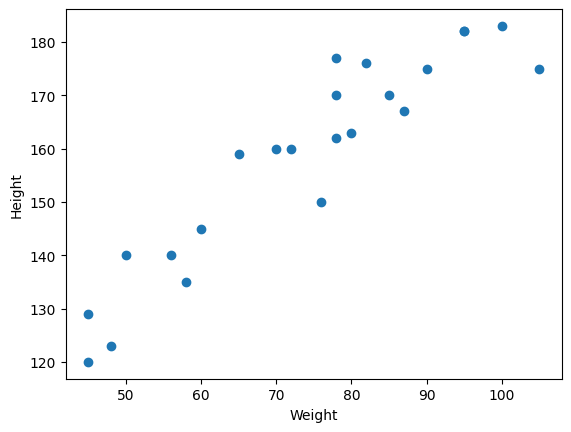

In [4]:
plt.scatter(df.Weight, df.Height)
plt.xlabel('Weight')
plt.ylabel('Height')
plt.show()  

#steps to perform simple linear regression

#1 divide data into dependent and independent variables

#2 train test split

standardize the dATA for independent features must include 2d array by adding [[]]

train the model(predict formula)

performance metrics(mse,mae,rmse,r2,adjusted r2)- (y_test & y_pred)



In [5]:
x = df[['Weight']]
y = df['Height']    


In [6]:
#train test split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [7]:
#STANDARDIZE THE DATA for independent features must include 2d array by adding [[]]
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [8]:
#train the model
from sklearn.linear_model import LinearRegression   
model = LinearRegression()
model.fit(x_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [9]:
slope = model.coef_  #slope
intercept = model.intercept_  #y intercept
slope,intercept



(array([17.03440872]), np.float64(157.5))

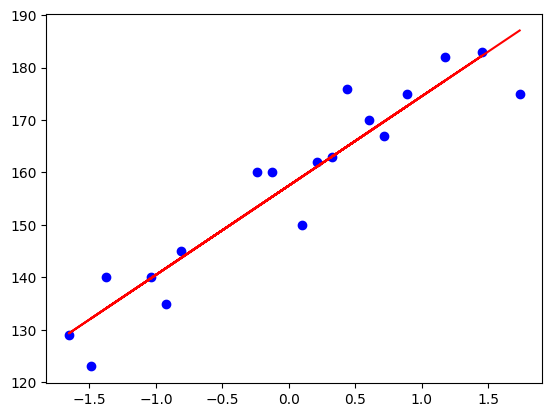

In [10]:
plt.scatter(x_train, y_train, color='blue')
plt.plot(x_train, model.predict(x_train), color='red')

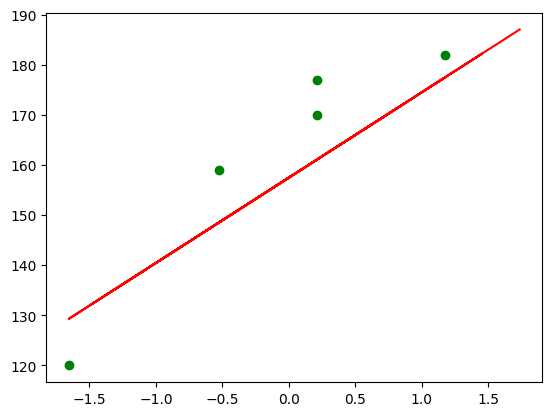

In [11]:
y_pred_test = model.predict(x_test)
y_pred_train = model.predict(x_train)
plt.scatter(x_test, y_test, color='green')
plt.plot(x_train, model.predict(x_train), color='red')

In [12]:
#performance metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred_test)
mae = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_test)
adjusted_r2 = 1 - (1 - r2) * (len(y_test) - 1) / (len(y_test) - x_test.shape[1] - 1)
mse, mae, rmse, r2, adjusted_r2

(109.77592599051664,
 9.822657814519232,
 np.float64(10.477400726827081),
 0.776986986042344,
 0.7026493147231252)

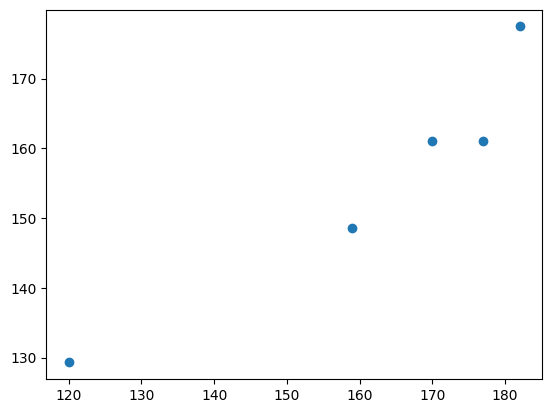

In [ ]:
## assumptions for testing
plt.scatter(y_test, y_pred_test)# this must be linear after final run

<Axes: xlabel='Height', ylabel='Count'>

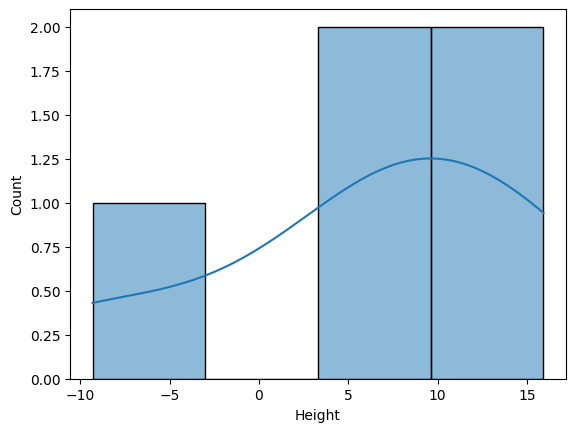

In [ ]:
#assumption-2 residuals must be normally distributed
import seaborn as sns
residuals = y_test - y_pred_test
sns.histplot(residuals, kde=True)

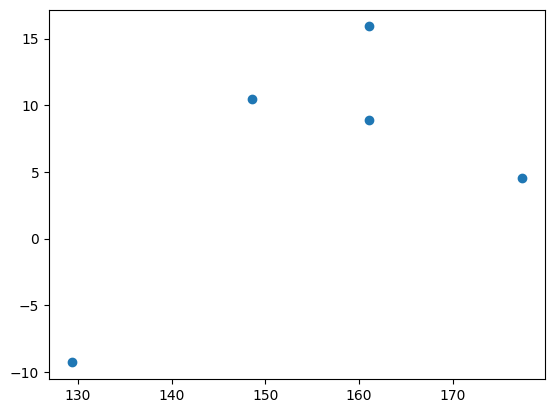

In [16]:
## assumption-3 residuals and ypred must be uniform distribution
plt.scatter(y_pred_test, residuals)